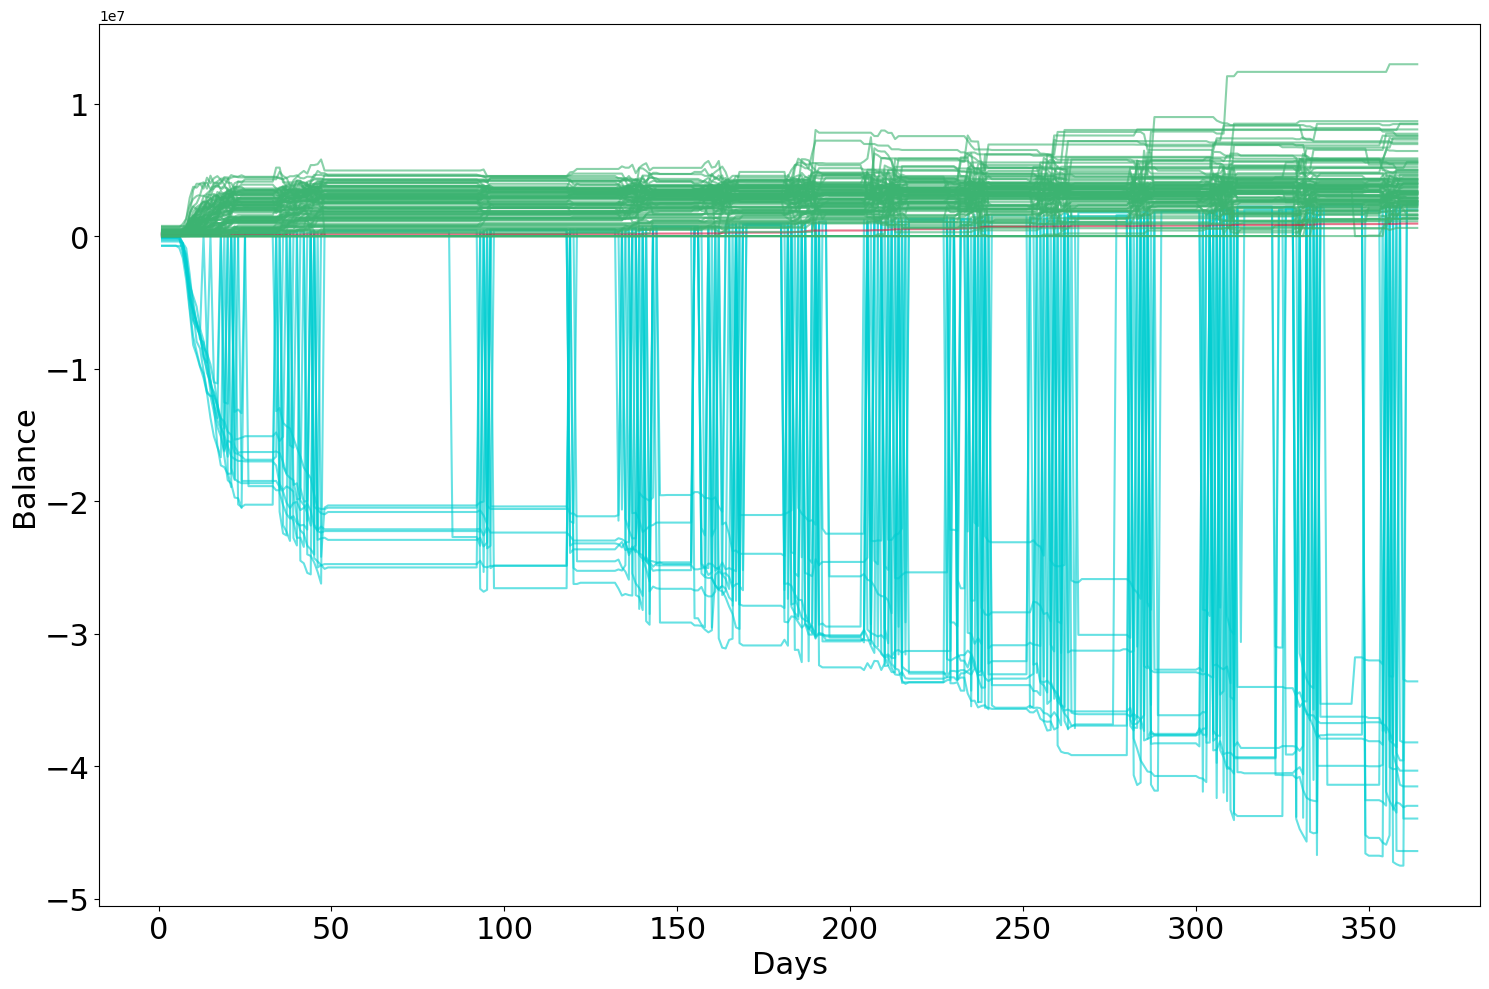

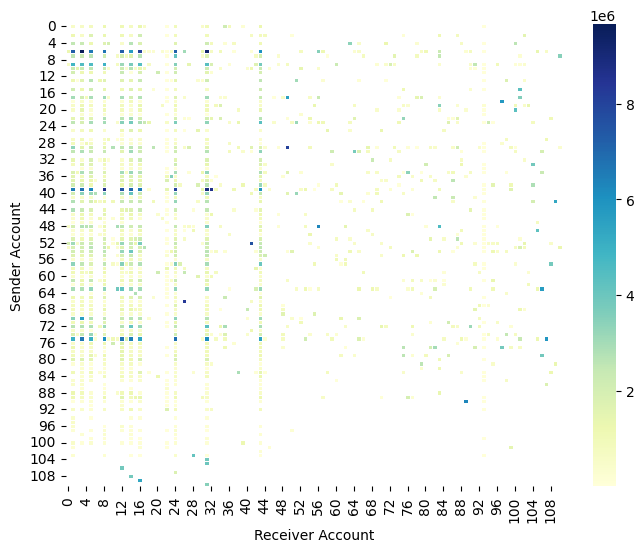


----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    2.763964e+01
 Y:         111 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* compute sample covariance matrix S: nnz(S)/p=3.36e+00 time=1.21e-03
* iter=1 time=1.79e-03 obj=1.82e+02 |delta(obj)|/obj=3.92e-01 nnz(X,L,W)/p=[3.36e+00 2.09e+00 1.52e+00] lns_iter=2 
* iter=2 time=2.99e-03 obj=1.82e+02 |delta(obj)|/obj=6.43e-06 nnz(X,L,W)/p=[3.36e+00 2.09e+00 4.62e+00] lns_iter=1 
#SQUIC Finished: time=6.62e-03 nnz(X,W)

/opt/anaconda3/envs/bank/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/opt/anaconda3/envs/bank/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/opt/anaconda3/envs/bank/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/opt/anaconda3/envs/bank/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/opt/anaconda3/envs/bank/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expecte

In [27]:
from workflow.internal import *

# Load dataset (the user will pass the name)
df, name, dimension = load_dataset()

# Extract time series
extract_timeseries(df, name)

# Normalise time series
Y_norm = normalization(df, name)

# Create transaction matrix
adj_matrix = adjaceny_matrix(Y_norm, name, dimension)

# Run SQUIC_fit
W_matrices, _ = squic_fit_computation(Y_norm, name, dimension, adj_matrix, printMatrix=False)

# Use the extracted W for clustering
dict_cluster = clustering(W_matrices)

# Report internal metrics on the clustering
int_metrics = internal_metrics(dict_cluster, W_matrices)

In [28]:
visualize_metrics(int_metrics)

For rho = 0.9
    louvain : {'ncut': 1.57, 'rcut': 0.31, 'modularity': 0.2, 'CC': 82, 'nCluster': 85}
    dbscan : {'ncut': 0.0, 'rcut': 0.0, 'modularity': -0.0, 'CC': 82, 'nCluster': 1}
    spectral : {'ncut': 2.28, 'rcut': 0.28, 'modularity': 0.14, 'CC': 82, 'nCluster': 6}


For rho = 0.5
    louvain : {'ncut': 1.75, 'rcut': 0.96, 'modularity': 0.45, 'CC': 9, 'nCluster': 13}
    dbscan : {'ncut': 7.09, 'rcut': 5.52, 'modularity': 0.0, 'CC': 9, 'nCluster': 8}
    spectral : {'ncut': 4.17, 'rcut': 1.6, 'modularity': 0.4, 'CC': 9, 'nCluster': 10}


For rho = 0.2
    louvain : {'ncut': 1.81, 'rcut': 2.88, 'modularity': 0.45, 'CC': 2, 'nCluster': 7}
    dbscan : {'ncut': 102.67, 'rcut': 164.92, 'modularity': -0.01, 'CC': 2, 'nCluster': 103}
    spectral : {'ncut': 0.87, 'rcut': 1.33, 'modularity': 0.38, 'CC': 2, 'nCluster': 4}


For rho = 0.1
    louvain : {'ncut': 2.14, 'rcut': 6.55, 'modularity': 0.4, 'CC': 1, 'nCluster': 6}
    dbscan : {'ncut': 104.61, 'rcut': 319.1, 'modularity': -0.

In [43]:
def extract_results(metrics):
    # Initialize the rho_values list and dictionaries for each algorithm and metric
    rho_values = list(metrics.keys())
    
    # Initialize empty lists for each algorithm and metric
    lists_dict = {
        'rho_values': rho_values,
        'louvain_ncut': [],
        'dbscan_ncut': [],
        'spectral_ncut': [],
        'louvain_rcut': [],
        'dbscan_rcut': [],
        'spectral_rcut': [],
        'louvain_modularity': [],
        'dbscan_modularity': [],
        'spectral_modularity': [],
        'louvain_CC': [],
        'dbscan_CC': [],
        'spectral_CC': [],
        'louvain_nCluster': [],
        'dbscan_nCluster': [],
        'spectral_nCluster': []
    }
    
    # Extract values for each rho value
    for rho in rho_values:
        for algorithm in ['louvain', 'dbscan', 'spectral']:
            if algorithm in metrics[rho]:
                result = metrics[rho][algorithm]
                for metric in ['ncut', 'rcut', 'modularity', 'CC', 'nCluster']:
                    if metric in result:
                        lists_dict[f'{algorithm}_{metric}'].append(result[metric])
                    else:
                        lists_dict[f'{algorithm}_{metric}'].append(None)  # Handle missing metrics
            else:
                # Handle case where an algorithm is missing for a rho value
                for metric in ['ncut', 'rcut', 'modularity', 'CC', 'nCluster']:
                    lists_dict[f'{algorithm}_{metric}'].append(None)
    
    return lists_dict

In [30]:
# Visualise with cosmograph
# widget_dict = visualize_graph(W_matrices, dict_cluster, name, dimension)

In [31]:
# rho = 0.5

In [32]:
# widget_dict[rho]['louvain']

In [33]:
# widget_dict[rho]["spectral"]

In [34]:
# widget_dict[rho]["dbscan"]

In [42]:
lists = extract_results(int_metrics)
lists

[0.9, 0.5, 0.2, 0.1, 0.09, 0.05, 0.02, 0.01, 0.001]


{'rho_values': [0.9, 0.5, 0.2, 0.1, 0.09, 0.05, 0.02, 0.01, 0.001],
 'louvain_ncut': [1.57, 1.75, 1.81, 2.14, 2.2, 2.58, 4.06, 3.52, 4.15],
 'dbscan_ncut': [0.0,
  7.09,
  102.67,
  104.61,
  104.62,
  110.0,
  111.0,
  111.0,
  111.0],
 'spectral_ncut': [2.28, 4.17, 0.87, 4.77, 0.81, 0.59, 0.85, 0.57, 0.88],
 'louvain_rcut': [0.31, 0.96, 2.88, 6.55, 6.97, 14.15, 48.55, 73.99, 276.74],
 'dbscan_rcut': [0.0,
  5.52,
  164.92,
  319.1,
  351.65,
  606.11,
  1326.48,
  2240.29,
  7225.42],
 'spectral_rcut': [0.28, 1.6, 1.33, 12.12, 1.63, 0.69, 4.88, 12.33, 47.64],
 'louvain_modularity': [0.2, 0.45, 0.45, 0.4, 0.39, 0.35, 0.28, 0.25, 0.14],
 'dbscan_modularity': [-0.0,
  0.0,
  -0.01,
  -0.01,
  -0.01,
  -0.01,
  -0.01,
  -0.01,
  -0.01],
 'spectral_modularity': [0.14, 0.4, 0.38, 0.35, 0.32, 0.01, 0.01, 0.2, 0.04],
 'louvain_CC': [82, 9, 2, 1, 1, 1, 1, 1, 1],
 'dbscan_CC': [82, 9, 2, 1, 1, 1, 1, 1, 1],
 'spectral_CC': [82, 9, 2, 1, 1, 1, 1, 1, 1],
 'louvain_nCluster': [85, 13, 7, 6, 6, 6, 

In [44]:
def plot_results(metrics, ylabel, results):
    # Create the plot
    plt.figure(figsize=(6, 6))

    plt.plot(results['rho_values'], results[f'louvain_{metrics}'], 'o-', label='Louvain', color='steelblue')
    plt.plot(results['rho_values'], results[f'spectral_{metrics}'], 's-', label='Spectral', color='gold')
    plt.plot(results['rho_values'], results[f'dbscan_{metrics}'], '^-', label='DBSCAN', color='indianred')

    plt.xlabel('Reg. Parameter (λ)')
    plt.ylabel(ylabel)
    plt.xscale('log')
    plt.legend()
    plt.show()

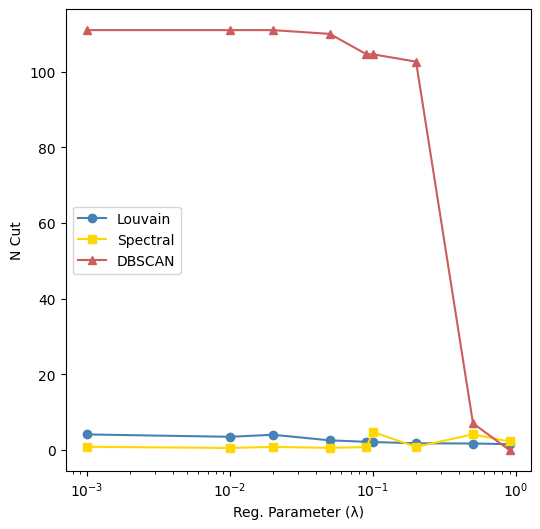

In [45]:
plot_results('ncut', 'N Cut', lists)

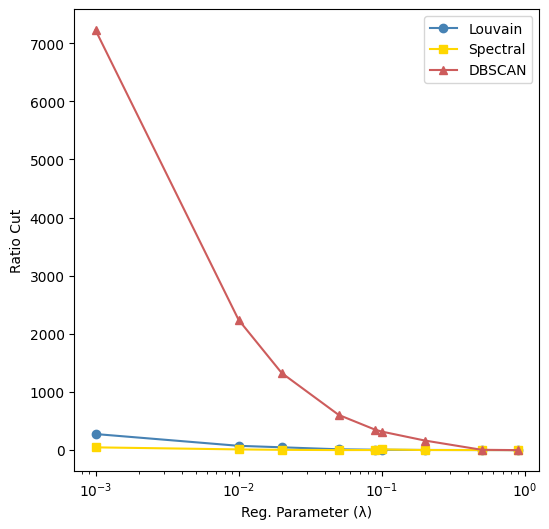

In [46]:
plot_results('rcut', 'Ratio Cut', lists)

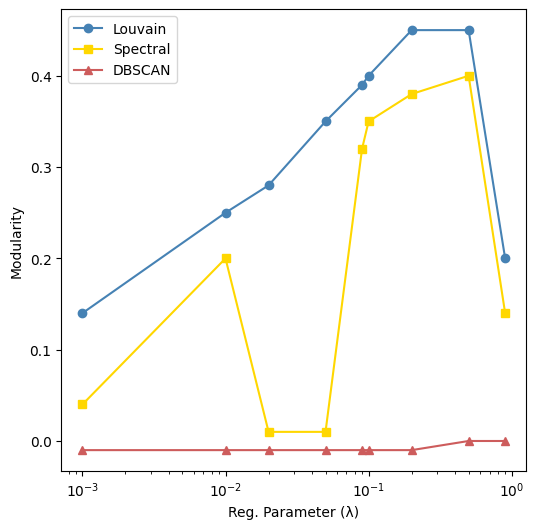

In [47]:
plot_results('modularity', 'Modularity', lists)

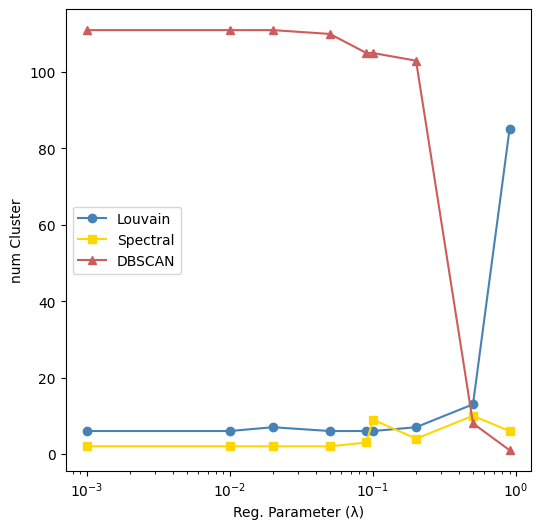

In [49]:
plot_results('nCluster', 'num Cluster', lists)